In [ ]:
# Step 1 : Import required libs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as s
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
# Step 2 : Load the Dataset

iris=load_iris()
print(iris.data[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [ ]:
# Step 3 : Convert the Dataset into Dataframes

df=pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# Step 4 : Other Info-check Datatypes and Null Values

print("\nShape : ",df.shape)
print("Info  :\n",df.info)
print("Descriptive Statistics \n",df.describe())
print("\nMissing Values :\n",df.isnull().sum())


Shape :  (150, 4)
Info  :
 <bound method DataFrame.info of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[15

In [ ]:
# Step 5 : Select Features and Targets

X=df.values
print(X[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


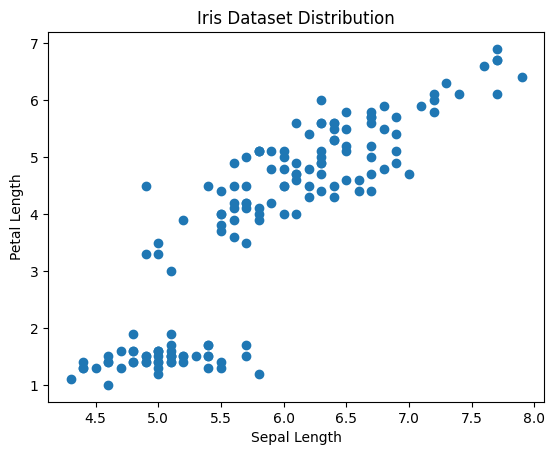

In [ ]:
# Step 6 : Visualization of Dataset
plt.scatter(df['sepal length (cm)'],df['petal length (cm)'])
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Iris Dataset Distribution")
plt.show()

In [ ]:
# Step 7 : Standardization

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

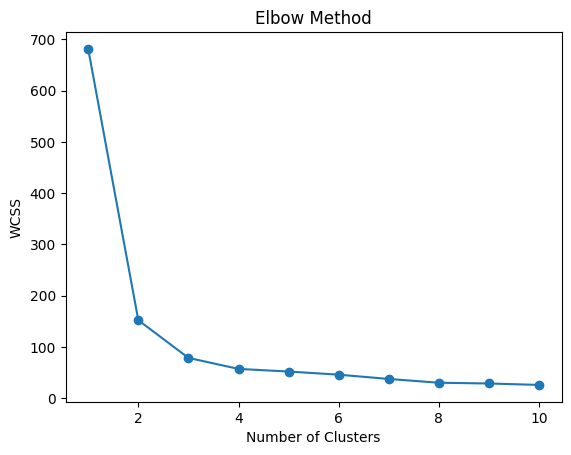

In [ ]:
# Step 8 :Determine the Optimal Number of clusters using Elbow Method

wcss=[]

for i in range(1,11):
  kmeans=KMeans(n_clusters=i)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

**(Part B) Applying K-Means to the Iris dataset**

In [ ]:
# Step 9 : Apply KMean Clustering

kmeans= KMeans(n_clusters=3)
kmeans.fit(X_scaled)

KMeans(n_clusters=3)

In [ ]:
# Step 10 : Predict Cluster Labels

clusters = kmeans.predict(X_scaled)
df['Clsuter']=clusters
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Clsuter  
0        1  
1        1  
2        1  
3        1  
4        1  


In [ ]:
# Step 11 : Find Cluster Centers

centroids=kmeans.cluster_centers_
print(centroids)

[[-0.01139555 -0.87600831  0.37707573  0.31115341]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.16743407  0.14530299  1.00302557  1.0300019 ]]


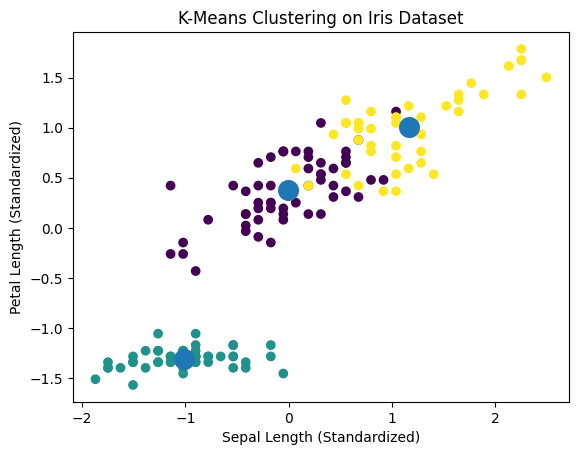

In [ ]:
# Step 12 : Visualize Clusters

plt.scatter(X_scaled[:,0], X_scaled[:,2], c=clusters)

plt.scatter(centroids[:,0],centroids[:,2],
marker='o',s=200)

plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Petal Length (Standardized)")
plt.title("K-Means Clustering on Iris Dataset")
plt.show()

In [ ]:
# Step 13 : Display Final Cluster Sizes and Final Centroids

final_labels = clusters
cluster_sizes = np.bincount(final_labels)

print("Final Cluster Sizes:")
for i, size in enumerate(cluster_sizes):
    print(f"Cluster {i}: {size} observations")

print("\nFinal Centroids:")
print(centroids)

Final Cluster Sizes:
Cluster 0: 56 observations
Cluster 1: 50 observations
Cluster 2: 44 observations

Final Centroids:
[[-0.01139555 -0.87600831  0.37707573  0.31115341]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.16743407  0.14530299  1.00302557  1.0300019 ]]


In [ ]:
# Step 14 : Convert Centroids Back to Original Units

final_centroids = scaler.inverse_transform(centroids)

print("Final Centroids in Original Units:")
print(final_centroids)

Final Centroids in Original Units:
[[5.83392857 2.67678571 4.42142857 1.43571429]
 [5.006      3.428      1.462      0.246     ]
 [6.80681818 3.12045455 5.52272727 1.98181818]]


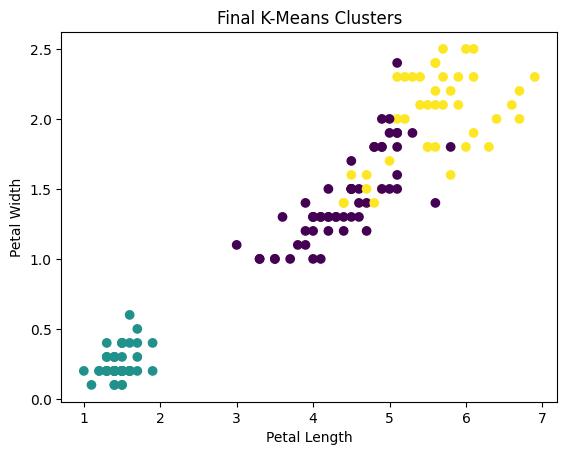

In [ ]:
# Step 15 : Visualize Final Clusters using Petal Length and Petal Width

plt.scatter(
    X[:, 2],
    X[:, 3],
    c=final_labels
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Final K-Means Clusters")
plt.show()

In [ ]:
# Step 16 : Calculate Silhouette Score

silhouette=silhouette_score(
    X_scaled,
    final_labels
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.4630
